In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Logistic Regression Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)


class LogisticRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.b_ = 0.0
        self.loss_ = []

        rgen = np.random.default_rng(self.random_state)
        self.w_ = rgen.normal(loc=0, scale=0.3, size=X.shape[1])

        for i in range(self.n_iter):
            z = self.net_input(X)
            output = self.activation(z)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()

            log_loss = (-y.dot(np.log(output))) - ((1-y).dot(np.log(1-output)))
            self.loss_.append(log_loss)

    def net_input(self, X):
        # calculate and return net input
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        # return the sigmoid function
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):    
        # predict class label
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0) 


In [3]:
# plotting decision regions
def plot_decision_regions(X, y, model, resolution=0.01):
    
    # color map
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    markers = ('o', 's', '^', 'v', '<')
    colmap = ListedColormap(colors[:len(np.unique(y))])

    # creating grid
    h_min, h_max = X[:,0].min()-1, X[:,0].max()+1
    v_min, v_max = X[:,1].min()-1, X[:,1].max()+1

    hh, vv = np.meshgrid(np.arange(h_min, h_max, resolution), 
                         np.arange(v_min, v_max, resolution))
    grid = np.c_[hh.ravel(), vv.ravel()] #transpose the data into required format

    # predicting class for each grid point
    grid_col = model.predict(grid)
    grid_col = grid_col.reshape(hh.shape)

    # plot decision regions
    plt.contourf(hh, vv, grid_col, alpha=0.3, cmap=colmap)
    plt.xlim(h_min, h_max)
    plt.ylim(v_min, v_max)

    # plotting sample data points over the decision regions
    for i, val in enumerate(np.unique(y)):
        plt.scatter(X[y==val, 0], X[y==val, 1], c=colors[i], marker=markers[i],
        label=f"Class {val}")

    plt.legend()

In [4]:
# Importing and cleaning dataset
data = pd.read_csv("../data/iris.data")
X = data.iloc[0:100, [0,2]].to_numpy()
# print(X[:5])

y = data.iloc[0:100, 4]
y = np.where(y=='Iris-setosa', 0, 1)

# feature scaling using standardization method
X_std = np.copy(X)
X_std[:,0] = (X[:,0]-X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1]-X[:,1].mean())/X[:,1].std()

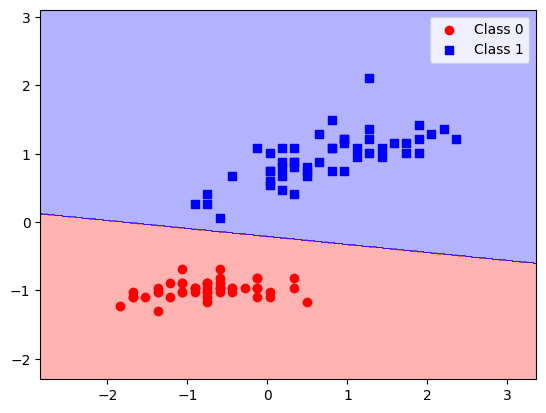

In [5]:
# fitting model on the data
lg = LogisticRegressionGD(eta=0.3, n_iter=500, random_state=1)
lg.fit(X_std, y)

plot_decision_regions(X_std, y, lg, 0.01)


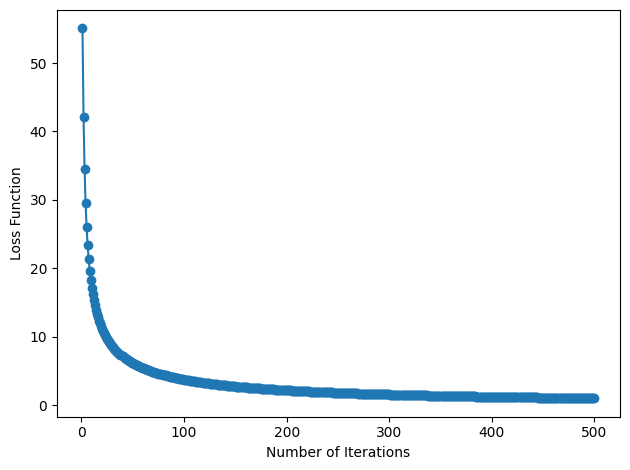

In [6]:
plt.plot(range(1, lg.n_iter+1), lg.loss_, marker='o')
plt.xlabel("Number of Iterations")
plt.ylabel("Loss Function")
plt.tight_layout()
plt.show()